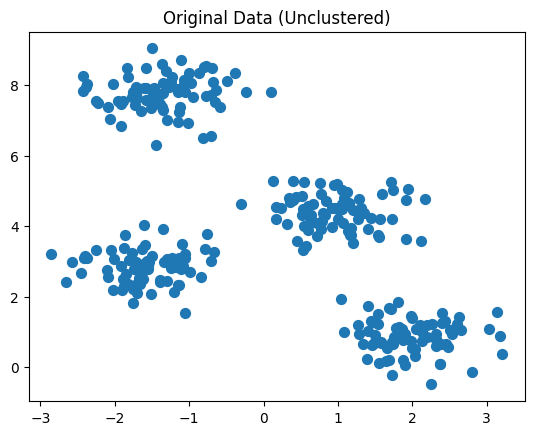

Estimated number of clusters: 4
Unique labels (including -1 for noise if present): {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(-1)}


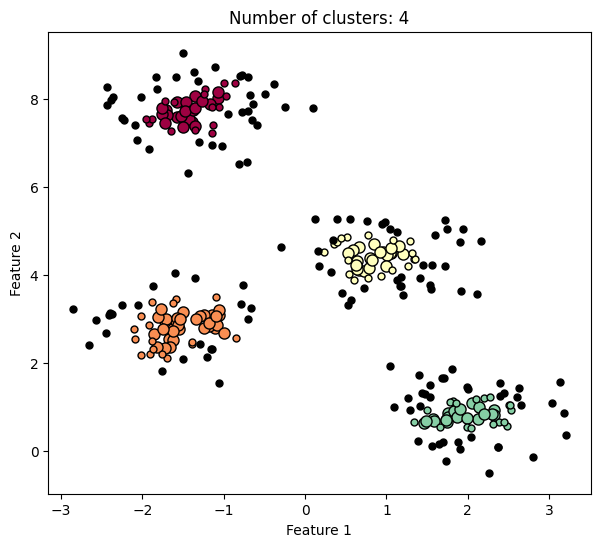

Silhouette Coefficient:0.13
Adjusted Rand Index: 0.31


In [5]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.datasets import make_blobs

# Create dataset with 4 centers (clusters)
#here X is the data coordinate and y_true is the label of the cluster that point is assigned to
X, y_true = make_blobs(n_samples=300, centers=4,
                       cluster_std=0.50, random_state=0)


# Visualize the raw data
#our data has shape (300,2) which means 300 rows and 2 cols
#here we are extracting first col and then second col which represent (x,y) coordinate
#s=50 is simply the size of the dot, not no of data points, we are plotting all data
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title("Original Data (Unclustered)")
plt.show()

# Apply DBSCAN
#radius around each point = 0.3
#min samples required in the radius to call it a core point = 10
db = DBSCAN(eps=0.3, min_samples=10).fit(X)

# Create a boolean mask initialized to False for all points
# This mask will later mark which points are core samples identified by DBSCAN
# db.labels_ might look like [0,0,0,1,1,1-1,2,2,2]
# these are the cluster labels of each point
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)

# Mark the core sample indices obtained from DBSCAN as True in the mask
# db.core_sample_idices might look like [0,1,2,7,8,9,10,12]
# these are the indexes of core points
core_samples_mask[db.core_sample_indices_] = True

# Extract the cluster labels assigned by DBSCAN to each point in the dataset
# Each point gets:
#   - A cluster label (0, 1, 2, ...)
#   - Or label = -1 for noise/outliers
labels = db.labels_

# Count the number of clusters found by DBSCAN
# DBSCAN may assign some points to noise (-1), so we subtract 1 if noise exists
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)                    #we are counting clusters bs DBscan only creates clusters doen't count them
print(f'Estimated number of clusters: {n_clusters_}')

# Get the set of unique labels produced by DBSCAN
# This includes cluster IDs and possibly -1 for noise
unique_labels = set(labels)                     #The set fucntion allows us to count unique values only
print('Unique labels (including -1 for noise if present):', unique_labels)

# Visualize the clustered data
# Generate one color per cluster (excluding noise)
# cm = colormap (gradient of colors)
# we are using linspace so that if 4 clusters, 4 evenly space numbers, which means 4 colors will be used, noise uses black later
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

plt.figure(figsize=(7, 6))

for k, col in zip(unique_labels, colors):     #zip is a function used to pair elements from two lsits together for eg (labels, colors)

    # Noise is colored black
    if k == -1:              # here k represents cluster label
        col = 'k'            # assign the col to k, which means black in matplotlib

    # with numpy, u can compare an array with a single value
    # here we want for each cluster,
    # 1. create a mask
    # 2. use this mask to plot only these points
    class_member_mask = (labels == k)

    # Plot core points
    # each cluster will have it's own core and border points, so we wanna apply both masks to get the points of that cluster only
    xy = X[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0], xy[:, 1], 'o',
        markerfacecolor=col,   #fill color
        markeredgecolor='k',   #black border
        markersize=8
    )

    # Plot border points
    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0], xy[:, 1], 'o',
        markerfacecolor=col,
        markeredgecolor='k',
        markersize=5          #smaller size as compared to core points
    )

plt.title(f"Number of clusters: {n_clusters_}")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Evaluation metrics (2 decimal place)
sc = metrics.silhouette_score(X, labels)
print("Silhouette Coefficient:%0.2f" % sc)
ari = metrics.adjusted_rand_score(y_true, labels)
print("Adjusted Rand Index: %0.2f" % ari)


Shape of dataset: (300, 3)

Data types:
 x1            float64
x2            float64
label_true      int64
dtype: object

Missing values per column:
 x1            0
x2            0
label_true    0
dtype: int64

Describe statistics:
                x1          x2  label_true
count  300.000000  300.000000  300.000000
mean     0.500413    0.253196    0.500000
std      0.871355    0.496069    0.500835
min     -1.104663   -0.563235    0.000000
25%     -0.063124   -0.197303    0.000000
50%      0.485312    0.248550    0.500000
75%      1.047578    0.713130    1.000000
max      2.131198    1.107772    1.000000


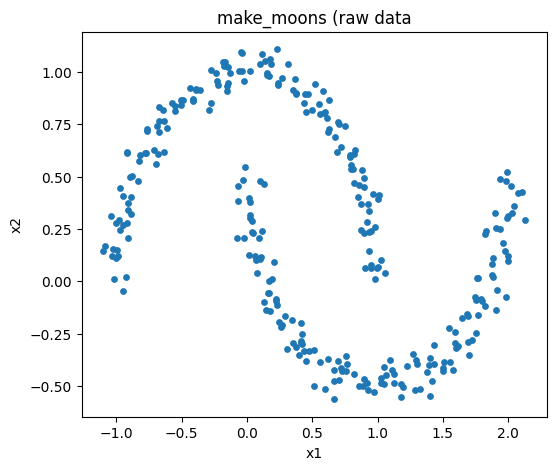


DBSCAN found number of clusters: 2
Unique labels: {np.int64(0), np.int64(1), np.int64(-1)}


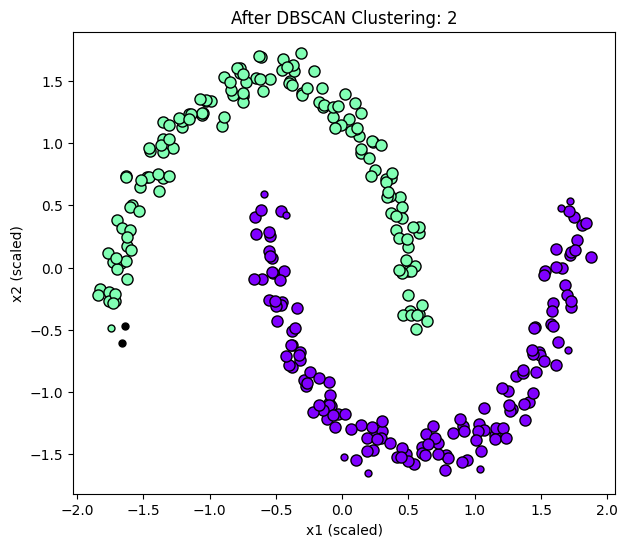

Silhouette Coefficient:0.17
Adjusted Rand Index: 0.99


In [9]:
# Task 2: DBSCAN on make_moons dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn import metrics

#Generate dataset
X, y_true = make_moons(n_samples=300, noise=0.05, random_state=42)

# Put into DataFrame for easier access
#now we have 3 cols, x1, x2 and label_ture
df = pd.DataFrame(X, columns=['x1', 'x2'])
df['label_true'] = y_true

# Explore the dataset
print("Shape of dataset:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values per column:\n", df.isnull().sum())
print("\nDescribe statistics:\n", df.describe())

# Visualize raw data
plt.figure(figsize=(6,5))
plt.scatter(df['x1'], df['x2'], s=15)
plt.title('make_moons (raw data')
plt.xlabel('x1'); plt.ylabel('x2')
plt.show()

# No cleaning required (no missing values) but we can scale features
# Z-score normalization (-3 to +3)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[['x1','x2']])

# Run DBSCAN
db = DBSCAN(eps=0.2, min_samples=5).fit(X_scaled)

labels = db.labels_

core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

unique_labels = set(labels)
n_clusters_ = len(unique_labels)

if -1 in unique_labels:
    n_clusters_ -= 1

print("\nDBSCAN found number of clusters:", n_clusters_)
print("Unique labels:", set(labels))

# Visualize clustered result
unique_labels = set(labels)
colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_labels))) #changed colors
plt.figure(figsize=(7,6))

for k, col in zip(unique_labels, colors):
    if k == -1:
        col = 'k'  # noise in black

    class_member_mask = (labels == k)

    # Core points
    xy = X_scaled[class_member_mask & core_samples_mask]
    if xy.size > 0:
        plt.plot(
            xy[:, 0],
            xy[:, 1], 'o',
            markerfacecolor=col,
            markeredgecolor='k',
            markersize=8
        )

    # Border points
    xy = X_scaled[class_member_mask & ~core_samples_mask]
    if xy.size > 0:
        plt.plot(
            xy[:, 0],
            xy[:, 1], 'o',
            markerfacecolor=col,
            markeredgecolor='k',
            markersize=5
        )

plt.title(f"After DBSCAN Clustering: {n_clusters_}")
plt.xlabel('x1 (scaled)'); plt.ylabel('x2 (scaled)')
plt.show()

#Evaluation Metrics
# Silhouette score
sc = metrics.silhouette_score(X, labels)
print("Silhouette Coefficient:%0.2f" % sc)

# Adjusted Rand Index
ari = metrics.adjusted_rand_score(y_true, labels)
print("Adjusted Rand Index: %0.2f" % ari)
